In [14]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from supabase import create_client

%matplotlib inline

project_root = Path.cwd().parent
env_path = project_root / ".env"

load_dotenv(dotenv_path=env_path, override=True)

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)


In [15]:
page_size = 1000
all_rows = []
start = 0

while True:
    response = (
        supabase
        .table("incident")
        .select("*")
        .order("Incident_ID")
        .range(start, start + page_size - 1)
        .execute()
    )

    data = response.data
    if not data:
        break

    all_rows.extend(data)
    start += page_size

incident_df = pd.DataFrame(all_rows)
incident_df["Number_Victims"] = pd.to_numeric(incident_df["Number_Victims"], errors="coerce")


In [16]:
page_size = 1000
all_rows = []
start = 0

while True:
    response = (
        supabase
        .table("shooter")
        .select("*")
        .order("Incident_ID")
        .range(start, start + page_size - 1)
        .execute()
    )

    data = response.data
    if not data:
        break

    all_rows.extend(data)
    start += page_size

shooter_df = pd.DataFrame(all_rows)


In [17]:
page_size = 1000
all_rows = []
start = 0

while True:
    response = (
        supabase
        .table("victim")
        .select("*")
        .order("Incident_ID")
        .range(start, start + page_size - 1)
        .execute()
    )

    data = response.data
    if not data:
        break

    all_rows.extend(data)
    start += page_size

victim_df = pd.DataFrame(all_rows)


In [18]:
page_size = 1000
all_rows = []
start = 0

while True:
    response = (
        supabase
        .table("weapon")
        .select("*")
        .order("Incident_ID")
        .range(start, start + page_size - 1)
        .execute()
    )

    data = response.data
    if not data:
        break

    all_rows.extend(data)
    start += page_size

weapon_df = pd.DataFrame(all_rows)


In [19]:
all_rows = []
start = 0
batch_size = 1000

while True:
    response = (
        supabase
        .table("enrollment_state_year_mat")
        .select("*")
        .range(start, start + batch_size - 1)
        .execute()
    )

    data = response.data

    if not data:
        break

    all_rows.extend(data)
    start += batch_size

enrollment_df = pd.DataFrame(all_rows)


In [20]:
valid_states = {
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY", "DC"
}

incident_df_from_1987 = incident_df[incident_df["State"].isin(valid_states)].copy()
incident_df_from_1987["Year"] = pd.to_numeric(incident_df_from_1987["Year"], errors="coerce")
incident_df_from_1987["Victims_Killed"] = pd.to_numeric(incident_df_from_1987["Victims_Killed"], errors="coerce").fillna(0)
incident_df_from_1987 = incident_df_from_1987.dropna(subset=["Year"]).copy()
incident_df_from_1987["Year"] = incident_df_from_1987["Year"].astype(int)
incident_df_from_1987 = incident_df_from_1987[incident_df_from_1987["Year"] >= 1987].copy()

incident_agg = (
    incident_df_from_1987
    .groupby(["State", "Year"], as_index=False)
    .size()
    .rename(columns={"size": "incident_count"})
)


In [21]:
enrollment_df["state"] = enrollment_df["state"].astype(str).str.upper()

state_abbrev = {
    "ALABAMA": "AL", "ALASKA": "AK", "ARIZONA": "AZ", "ARKANSAS": "AR",
    "CALIFORNIA": "CA", "COLORADO": "CO", "CONNECTICUT": "CT",
    "DELAWARE": "DE", "DISTRICT OF COLUMBIA": "DC", "FLORIDA": "FL",
    "GEORGIA": "GA", "HAWAII": "HI", "IDAHO": "ID", "ILLINOIS": "IL",
    "INDIANA": "IN", "IOWA": "IA", "KANSAS": "KS", "KENTUCKY": "KY",
    "LOUISIANA": "LA", "MAINE": "ME", "MARYLAND": "MD",
    "MASSACHUSETTS": "MA", "MICHIGAN": "MI", "MINNESOTA": "MN",
    "MISSISSIPPI": "MS", "MISSOURI": "MO", "MONTANA": "MT",
    "NEBRASKA": "NE", "NEVADA": "NV", "NEW HAMPSHIRE": "NH",
    "NEW JERSEY": "NJ", "NEW MEXICO": "NM", "NEW YORK": "NY",
    "NORTH CAROLINA": "NC", "NORTH DAKOTA": "ND", "OHIO": "OH",
    "OKLAHOMA": "OK", "OREGON": "OR", "PENNSYLVANIA": "PA",
    "RHODE ISLAND": "RI", "SOUTH CAROLINA": "SC",
    "SOUTH DAKOTA": "SD", "TENNESSEE": "TN", "TEXAS": "TX",
    "UTAH": "UT", "VERMONT": "VT", "VIRGINIA": "VA",
    "WASHINGTON": "WA", "WEST VIRGINIA": "WV",
    "WISCONSIN": "WI", "WYOMING": "WY"
}

enrollment_df["State"] = enrollment_df["state"].map(state_abbrev)
enrollment_df = enrollment_df.rename(columns={"year": "Year"})
enrollment_df["Year"] = pd.to_numeric(enrollment_df["Year"], errors="coerce")
enrollment_df["total_students"] = pd.to_numeric(enrollment_df["total_students"], errors="coerce")
enrollment_df = enrollment_df.dropna(subset=["State", "Year", "total_students"]).copy()
enrollment_df["Year"] = enrollment_df["Year"].astype(int)
enrollment_df = enrollment_df[enrollment_df["Year"] >= 1987].copy()
enrollment_df = (
    enrollment_df
    .sort_values("total_students", ascending=False)
    .drop_duplicates(["State", "Year"])
)


In [22]:
merged_df_table = enrollment_df.merge(
    incident_agg,
    on=["State", "Year"],
    how="left"
)

merged_df_table["incident_count"] = merged_df_table["incident_count"].fillna(0)
merged_df_table["incident_rate_per_100k"] = np.where(
    merged_df_table["total_students"] > 0,
    (merged_df_table["incident_count"] / merged_df_table["total_students"]) * 100000,
    np.nan
)
merged_df_table["risk_per_100k"] = merged_df_table["incident_rate_per_100k"]
merged_df_table = merged_df_table.drop(columns=["state"])
merged_df_table = merged_df_table.sort_values(["State", "Year"]).reset_index(drop=True)


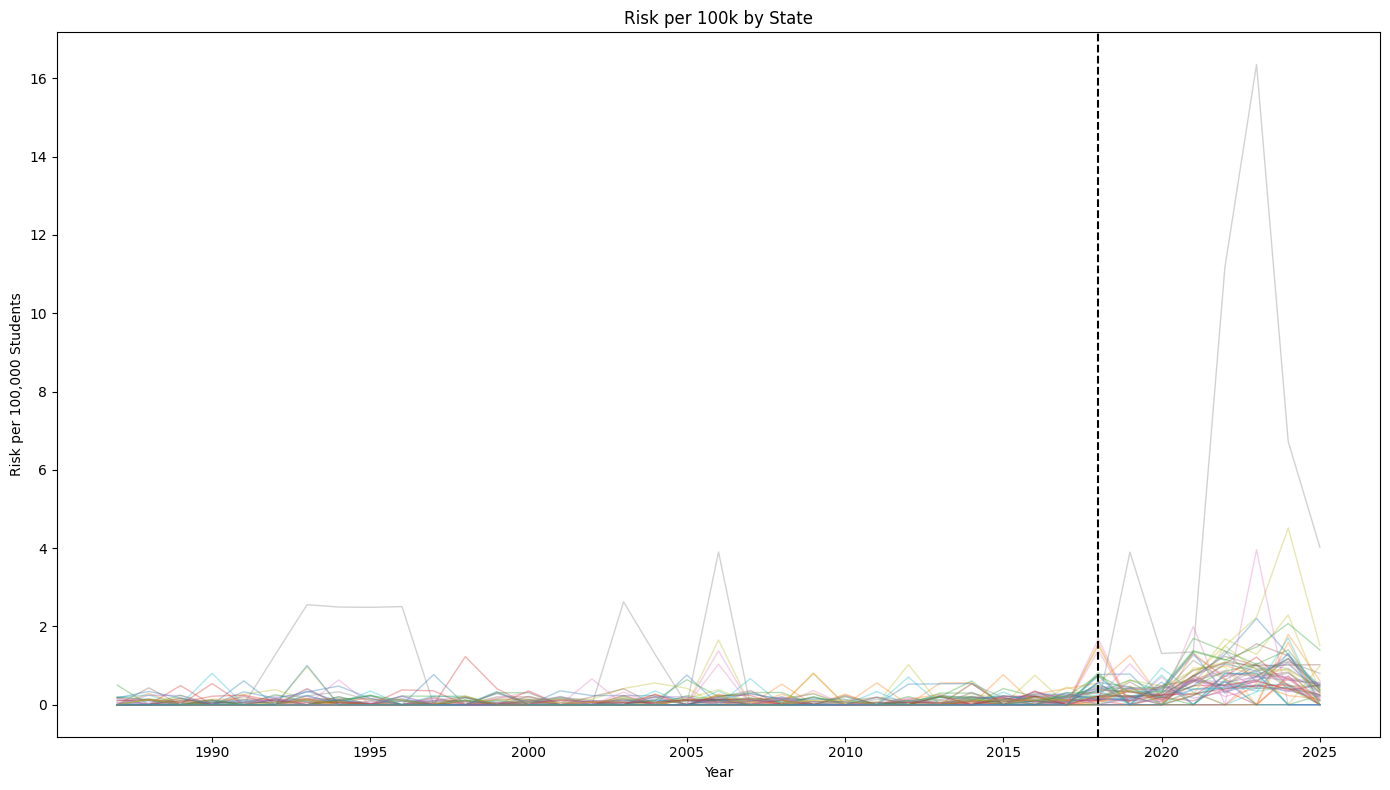

In [23]:
plt.figure(figsize=(14, 8))
for state, state_df in merged_df_table.groupby("State"):
    plt.plot(state_df["Year"], state_df["risk_per_100k"], alpha=0.35, linewidth=1)

plt.axvline(2018, color="black", linestyle="--", linewidth=1.5)
plt.xlabel("Year")
plt.ylabel("Risk per 100,000 Students")
plt.title("Risk per 100k by State")
plt.tight_layout()
plt.show()


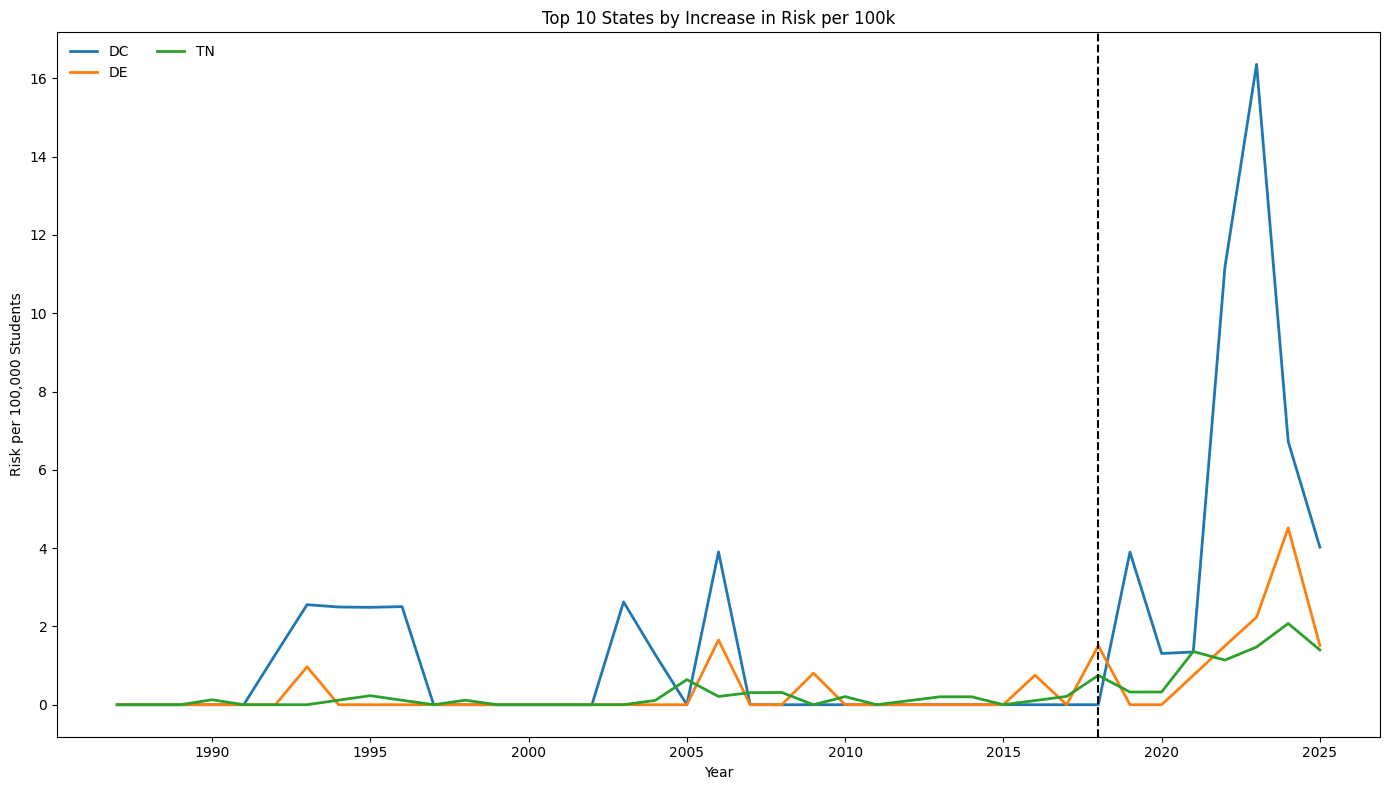

In [33]:
state_change = (
    merged_df_table
    .assign(period=np.where(merged_df_table["Year"] >= 2018, "post_2018", "pre_2018"))
    .groupby(["State", "period"])["risk_per_100k"]
    .mean()
    .unstack(fill_value=0)
)
state_change["increase"] = state_change.get("post_2018", 0) - state_change.get("pre_2018", 0)
top_states = state_change.sort_values("increase", ascending=False).head(3).index
focus_df = merged_df_table[merged_df_table["State"].isin(top_states)].copy()

plt.figure(figsize=(14, 8))
for state, state_df in focus_df.groupby("State"):
    plt.plot(state_df["Year"], state_df["risk_per_100k"], linewidth=2, label=state)

plt.axvline(2018, color="black", linestyle="--", linewidth=1.5)
plt.xlabel("Year")
plt.ylabel("Risk per 100,000 Students")
plt.title("Top 10 States by Increase in Risk per 100k")
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()


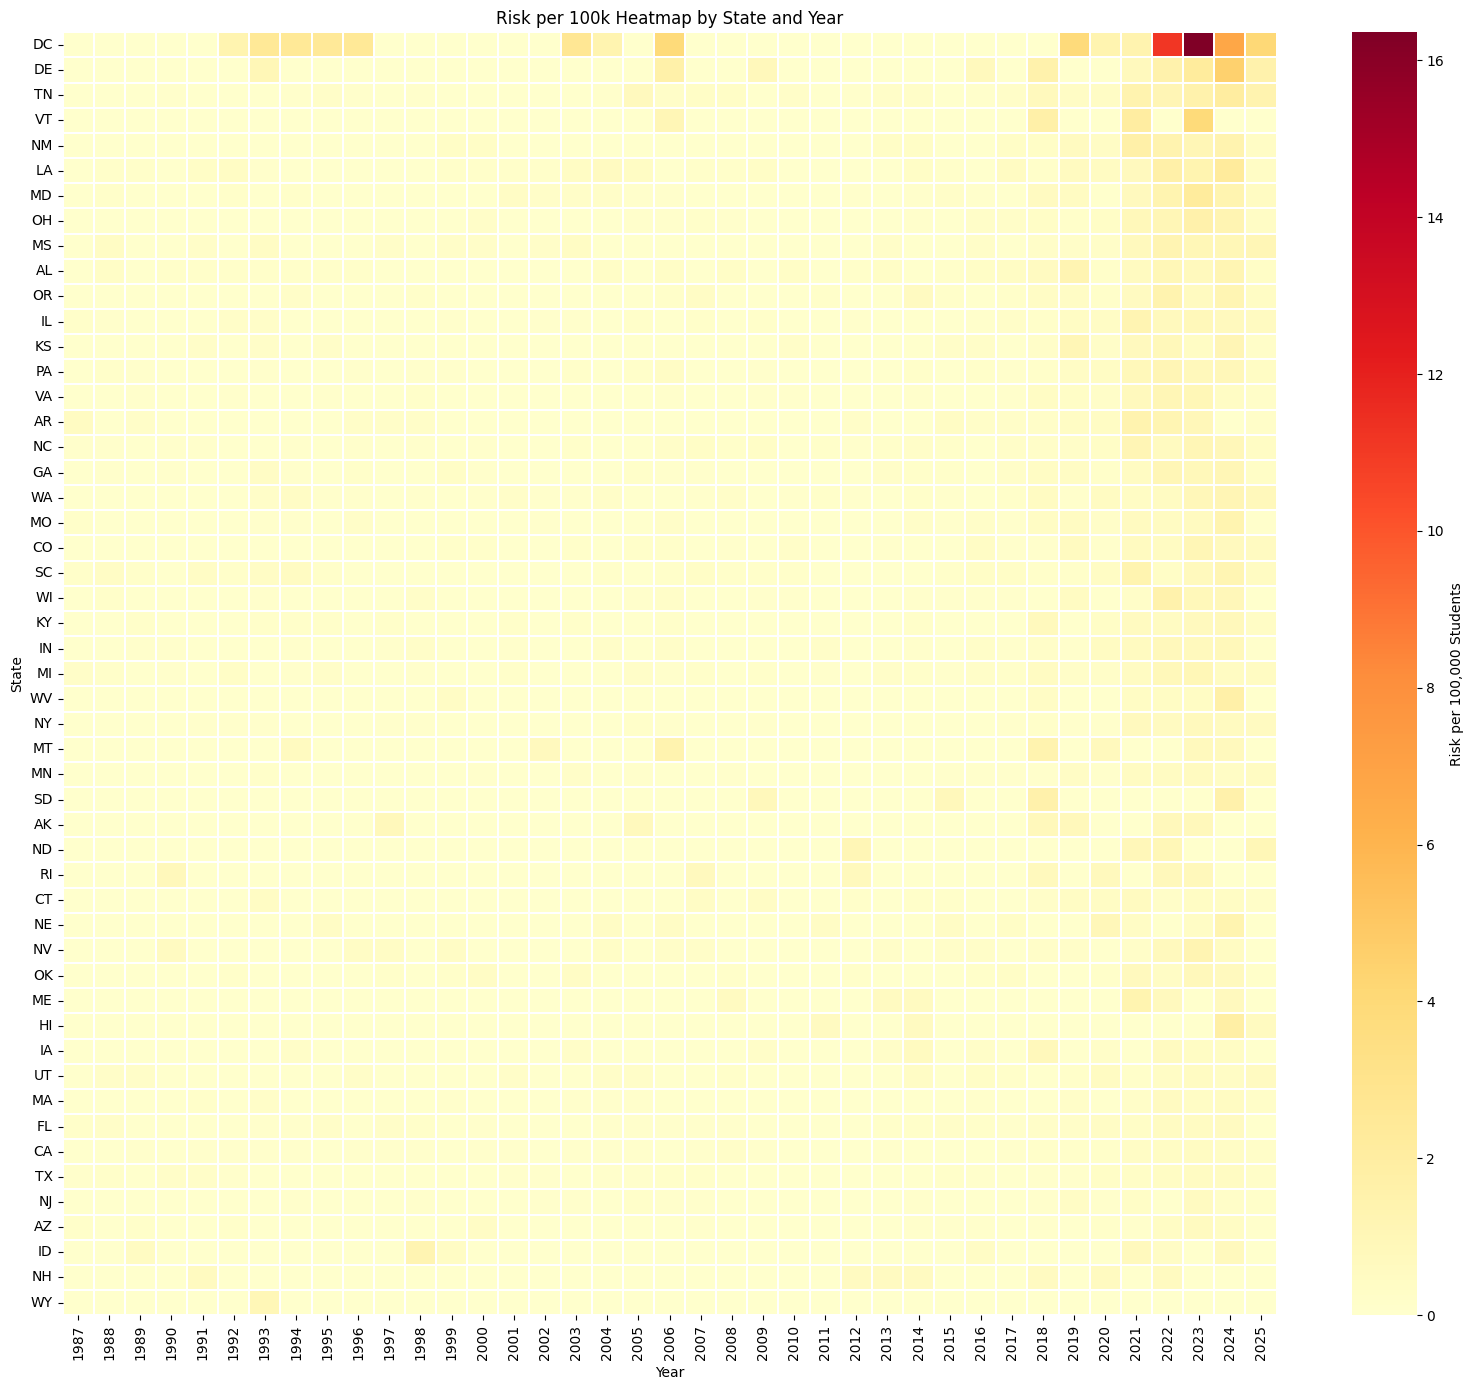

In [25]:
state_order = state_change.sort_values("increase", ascending=False).index
heatmap_df = (
    merged_df_table
    .pivot(index="State", columns="Year", values="risk_per_100k")
    .reindex(state_order)
    .fillna(0)
)

plt.figure(figsize=(16, 14))
sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    linewidths=0.1,
    linecolor="white",
    cbar_kws={"label": "Risk per 100,000 Students"}
)
plt.xlabel("Year")
plt.ylabel("State")
plt.title("Risk per 100k Heatmap by State and Year")
plt.tight_layout()
plt.show()


# smallest increase states

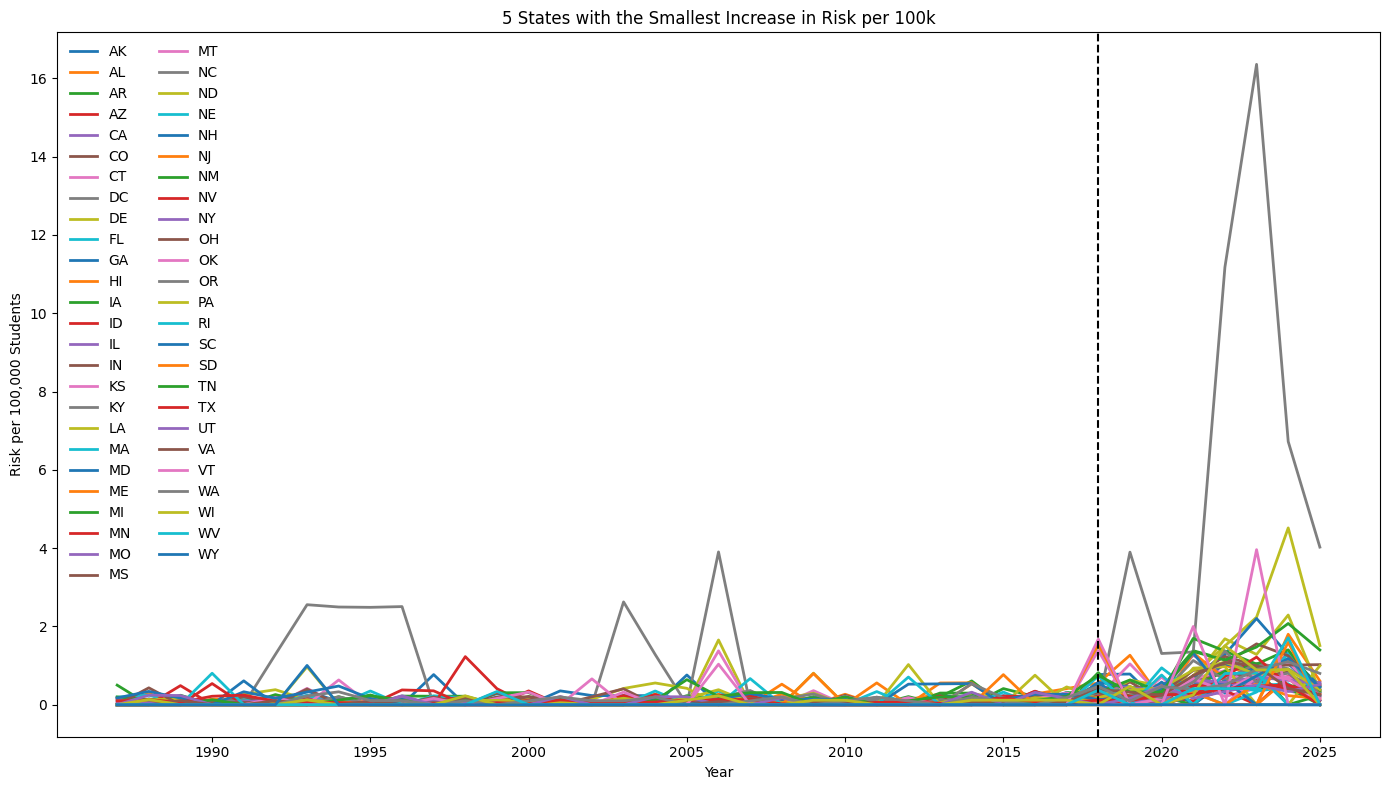

In [31]:
state_change = (
    merged_df_table
    .assign(period=np.where(merged_df_table["Year"] >= 2018, "post_2018", "pre_2018"))
    .groupby(["State", "period"])["risk_per_100k"]
    .mean()
    .unstack(fill_value=0)
)

state_change["increase"] = state_change.get("post_2018", 0) - state_change.get("pre_2018", 0)
lowest_increase_states = state_change.sort_values("increase", ascending=True).head(51).index
focus_df = merged_df_table[merged_df_table["State"].isin(lowest_increase_states)].copy()

plt.figure(figsize=(14, 8))
for state, state_df in focus_df.groupby("State"):
    plt.plot(state_df["Year"], state_df["risk_per_100k"], linewidth=2, label=state)

plt.axvline(2018, color="black", linestyle="--", linewidth=1.5)
plt.xlabel("Year")
plt.ylabel("Risk per 100,000 Students")
plt.title("5 States with the Smallest Increase in Risk per 100k")
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()


In [27]:
if "k12_settings_law" not in merged_df_table.columns:
    all_rows = []
    start = 0
    batch_size = 1000

    while True:
        response = (
            supabase
            .table("k12_settings_binary")
            .select("*")
            .range(start, start + batch_size - 1)
            .execute()
        )

        data = response.data
        if not data:
            break

        all_rows.extend(data)
        start += batch_size

    k12_df = pd.DataFrame(all_rows)

    merged_df_table = merged_df_table.merge(
        k12_df,
        left_on=["State", "Year"],
        right_on=["state", "year"],
        how="left"
    ).drop(columns=["state", "year"])

    merged_df_table["k12_settings_law"] = merged_df_table["k12_settings_law"].fillna(0)

implementation_years = (
    merged_df_table[
        (merged_df_table["State"].isin(lowest_increase_states)) &
        (merged_df_table["k12_settings_law"] == 1)
    ]
    .groupby("State", as_index=False)["Year"]
    .min()
    .rename(columns={"Year": "k12_settings_implementation_year"})
)

implementation_years = (
    pd.DataFrame({"State": list(lowest_increase_states)})
    .merge(implementation_years, on="State", how="left")
)

implementation_years["k12_settings_implementation_year"] = (
    implementation_years["k12_settings_implementation_year"]
    .fillna("Never adopted in panel")
)

implementation_years


,State,k12_settings_implementation_year
0,WY,2019.0
1,NH,Never adopted in panel
2,ID,Never adopted in panel
3,AZ,Never adopted in panel
4,NJ,Never adopted in panel
